EXERCISE 1


In [4]:
import pandas as pd

data = pd.read_csv('train.csv',index_col= 0)
print(data[data.duplicated()])
print(data)

Empty DataFrame
Columns: [Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []
             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   
...               ...     ...   
887                 0       2   
888                 1       1   
889                 0       3   
890                 1       1   
891                 0       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily Ma

In [5]:
clean_data = data.drop_duplicates(subset=['Name'])
print(clean_data)

             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   
...               ...     ...   
887                 0       2   
888                 1       1   
889                 0       3   
890                 1       1   
891                 0       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   
...       

EXERCISE 2

In [6]:
from sklearn.impute import SimpleImputer
import pandas as pd

data = pd.read_csv('train.csv',index_col= 0)
print(data)




             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   
...               ...     ...   
887                 0       2   
888                 1       1   
889                 0       3   
890                 1       1   
891                 0       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   
...       

In [7]:
manquants = data.isnull().sum()
print(manquants[manquants > 0])

Age         177
Cabin       687
Embarked      2
dtype: int64


In [8]:
#delete line that are contained NaN value
delete_data = data.dropna()
print(delete_data)

             Survived  Pclass  \
PassengerId                     
2                   1       1   
4                   1       1   
7                   0       1   
11                  1       3   
12                  1       1   
...               ...     ...   
872                 1       1   
873                 0       1   
880                 1       1   
888                 1       1   
890                 1       1   

                                                          Name     Sex   Age  \
PassengerId                                                                    
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
7                                      McCarthy, Mr. Timothy J    male  54.0   
11                             Sandstrom, Miss. Marguerite Rut  female   4.0   
12                                    Bonnell, Miss. Elizabeth  female  58.0   
...       

In [9]:
manual_change_data = data.fillna('Unknown')
print(manual_change_data)

             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   
...               ...     ...   
887                 0       2   
888                 1       1   
889                 0       3   
890                 1       1   
891                 0       3   

                                                          Name     Sex  \
PassengerId                                                              
1                                      Braund, Mr. Owen Harris    male   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female   
3                                       Heikkinen, Miss. Laina  female   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female   
5                                     Allen, Mr. William Henry    male   
...                                                 

In [10]:
from pandas.core.arrays import numeric
from sklearn.impute import SimpleImputer
import pandas as pd

data = pd.read_csv('train.csv',index_col= 0)

imputed = SimpleImputer(strategy='mean')

numeric_data = data.select_dtypes(include=['number']).columns
for col in numeric_data:
    imputed.fit(data[[col]])
    data[col] = imputed.transform(data[[col]])

print(data)

             Survived  Pclass  \
PassengerId                     
1                 0.0     3.0   
2                 1.0     1.0   
3                 1.0     3.0   
4                 1.0     1.0   
5                 0.0     3.0   
...               ...     ...   
887               0.0     2.0   
888               1.0     1.0   
889               0.0     3.0   
890               1.0     1.0   
891               0.0     3.0   

                                                          Name     Sex  \
PassengerId                                                              
1                                      Braund, Mr. Owen Harris    male   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female   
3                                       Heikkinen, Miss. Laina  female   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female   
5                                     Allen, Mr. William Henry    male   
...                                                 

EXERCISE 3

In [11]:
import pandas as pd

data = pd.read_csv('train.csv',index_col= 0)
print(data)

#create new feature
data["FamilySize"]= data["SibSp"] + data["Parch"]+1
#extract
data['Title'] = data['Name'].str.extract("([A-Za-z]+)\.",expand= False )
print (data)

             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   
...               ...     ...   
887                 0       2   
888                 1       1   
889                 0       3   
890                 1       1   
891                 0       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   
...       

<>:9: SyntaxWarning: invalid escape sequence '\.'
<>:9: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1637/4023017975.py:9: SyntaxWarning: invalid escape sequence '\.'
  data['Title'] = data['Name'].str.extract("([A-Za-z]+)\.",expand= False )


In [12]:
print(list(set(data['Title'])))
#simplify
data['Title'].replace(['Capt','Major','Don','Countess','Dr','Sir','Rev','Jonkheer','Col','Lady','Master'], 'Rare', inplace=True)
data['Title'].replace(['Ms','Mlle'],'Miss',inplace=True)
data['Title'].replace(['Mme'],'Mrs',inplace= True)
print(list(set(data['Title'])))
print(data)


['Mrs', 'Miss', 'Col', 'Master', 'Mr', 'Jonkheer', 'Countess', 'Dr', 'Ms', 'Capt', 'Rev', 'Lady', 'Don', 'Mme', 'Major', 'Sir', 'Mlle']
['Mrs', 'Rare', 'Miss', 'Mr']
             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   
...               ...     ...   
887                 0       2   
888                 1       1   
889                 0       3   
890                 1       1   
891                 0       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4   

/tmp/ipykernel_1637/2286114794.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Title'].replace(['Capt','Major','Don','Countess','Dr','Sir','Rev','Jonkheer','Col','Lady','Master'], 'Rare', inplace=True)


In [13]:
from numpy import mean
from sklearn.impute import SimpleImputer


Number = SimpleImputer(strategy ='median')
Object = SimpleImputer(strategy = 'most_frequent')
#imputation
Unknown_number = data.select_dtypes(include = ['number']).columns
unknown_object = data.select_dtypes(include = ['object']).columns

for col in Unknown_number:
    data[col] = Number.fit_transform(data[[col]])

for col in unknown_object:
    data[col] = Object.fit_transform(data[[col]]).ravel()

print(data)

             Survived  Pclass  \
PassengerId                     
1                 0.0     3.0   
2                 1.0     1.0   
3                 1.0     3.0   
4                 1.0     1.0   
5                 0.0     3.0   
...               ...     ...   
887               0.0     2.0   
888               1.0     1.0   
889               0.0     3.0   
890               1.0     1.0   
891               0.0     3.0   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   
...       

In [14]:
#encode
data['Sex']= data['Sex'].map({'male':0,'female':1})
data = pd.get_dummies(data,columns=['Title','Embarked'],drop_first=True)
print(data)

             Survived  Pclass  \
PassengerId                     
1                 0.0     3.0   
2                 1.0     1.0   
3                 1.0     3.0   
4                 1.0     1.0   
5                 0.0     3.0   
...               ...     ...   
887               0.0     2.0   
888               1.0     1.0   
889               0.0     3.0   
890               1.0     1.0   
891               0.0     3.0   

                                                          Name  Sex   Age  \
PassengerId                                                                 
1                                      Braund, Mr. Owen Harris    0  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0   
3                                       Heikkinen, Miss. Laina    1  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0   
5                                     Allen, Mr. William Henry    0  35.0   
...                            

In [15]:
#keep essential data
data.drop(['Name', 'Ticket', 'Cabin', 'PassengerId'],errors = 'ignore', axis=1, inplace=True)
print(data)

             Survived  Pclass  Sex   Age  SibSp  Parch     Fare  FamilySize  \
PassengerId                                                                   
1                 0.0     3.0    0  22.0    1.0    0.0   7.2500         2.0   
2                 1.0     1.0    1  38.0    1.0    0.0  71.2833         2.0   
3                 1.0     3.0    1  26.0    0.0    0.0   7.9250         1.0   
4                 1.0     1.0    1  35.0    1.0    0.0  53.1000         2.0   
5                 0.0     3.0    0  35.0    0.0    0.0   8.0500         1.0   
...               ...     ...  ...   ...    ...    ...      ...         ...   
887               0.0     2.0    0  27.0    0.0    0.0  13.0000         1.0   
888               1.0     1.0    1  19.0    0.0    0.0  30.0000         1.0   
889               0.0     3.0    1  28.0    1.0    2.0  23.4500         4.0   
890               1.0     1.0    0  26.0    0.0    0.0  30.0000         1.0   
891               0.0     3.0    0  32.0    0.0    0

EXERCSE 4


['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']


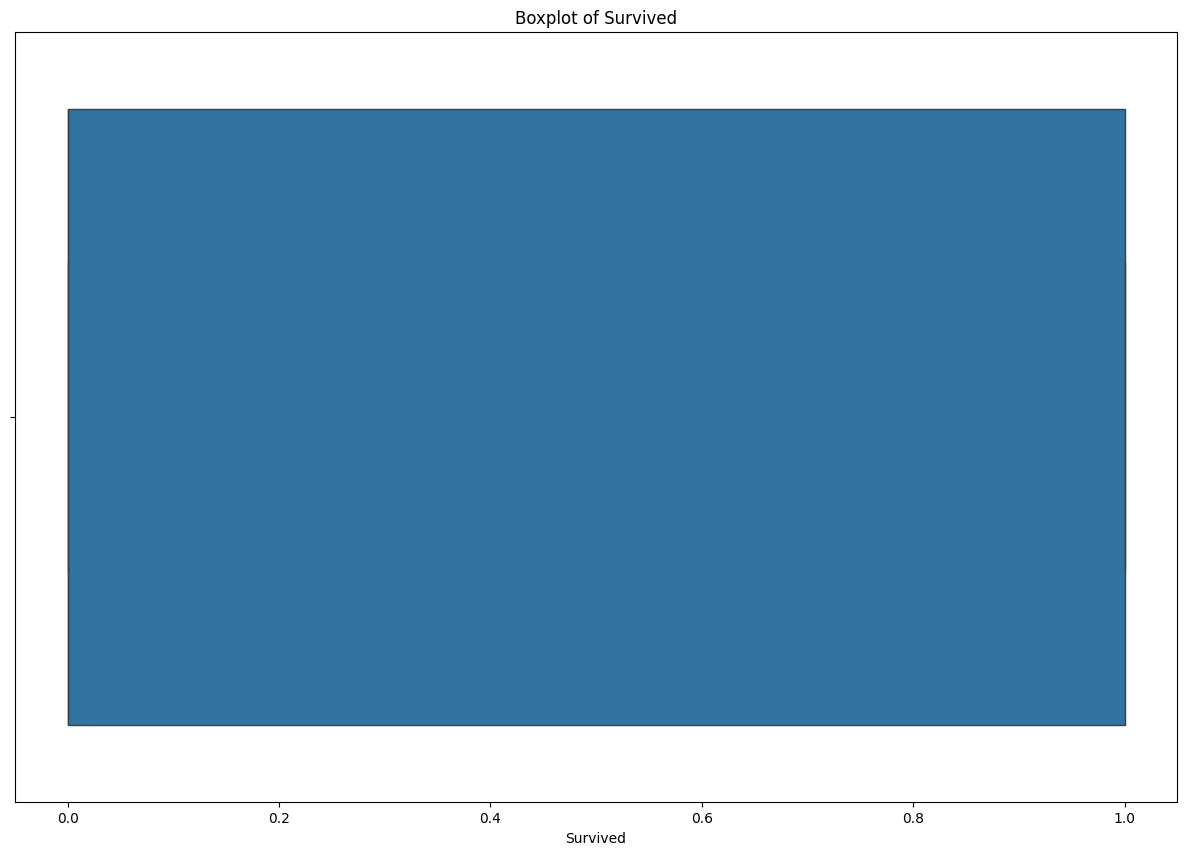

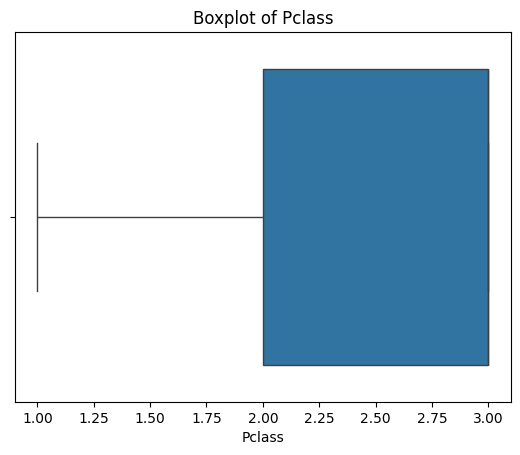

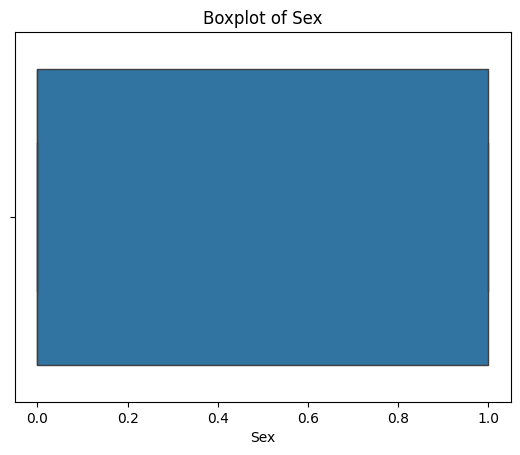

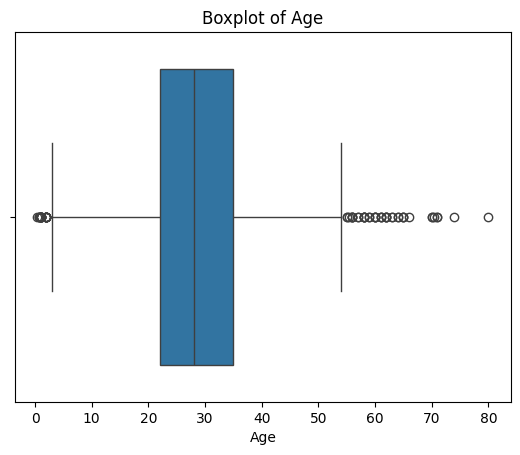

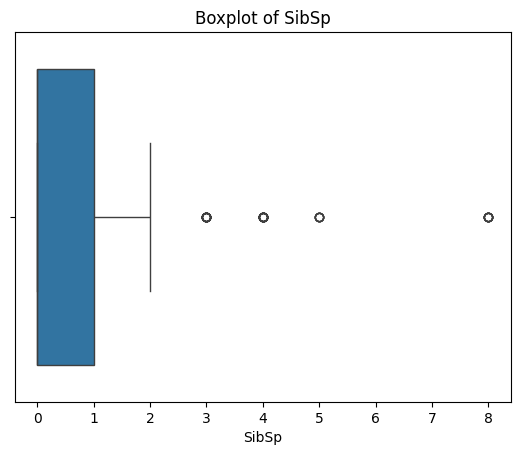

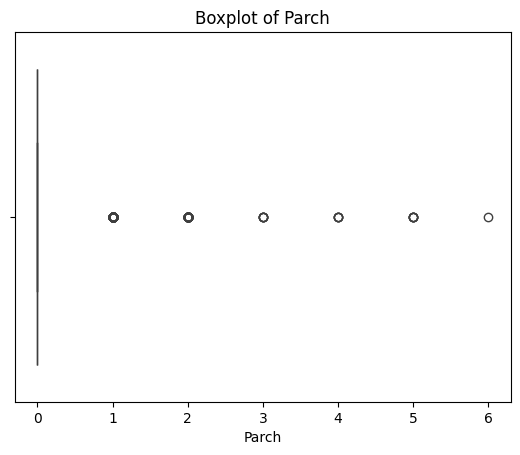

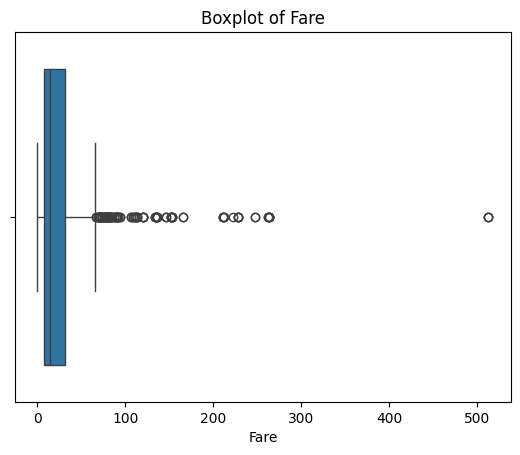

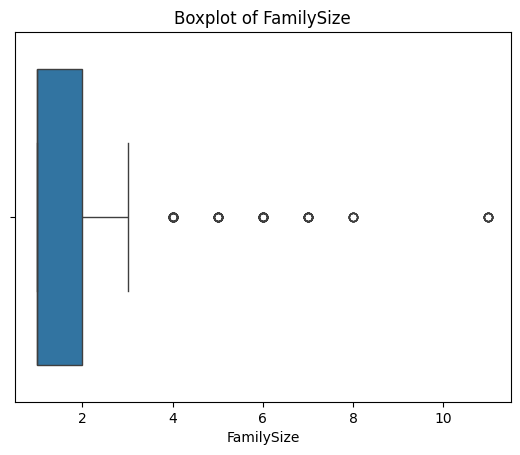

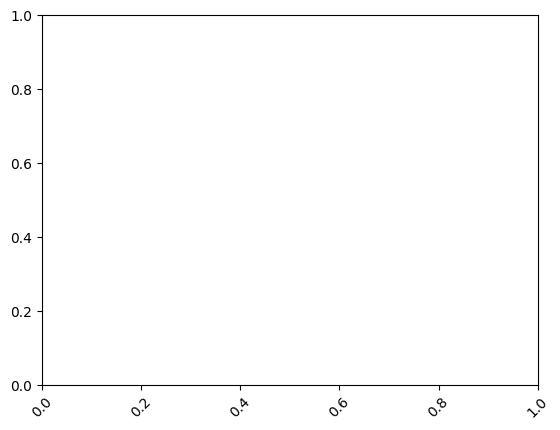

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = data.select_dtypes(include=['number']).columns
print(list(numeric_cols))

plt.figure(figsize=(15, 10))
for col in numeric_cols:
    sns.boxplot(data=data, x=f'{col}')
    plt.title(f"Boxplot of {col}")
    plt.show()

plt.xticks(rotation=45)
plt.show()



In [17]:
def detect_outliers_iqr (data , column) :
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)

  IQR = Q3-Q1

  lower = Q1 - 1.5*IQR
  upper = Q3 + 1.5*IQR

  return data[(data[column] > upper) | (data[column] < lower)]

In [18]:
outliers = {}
for col in numeric_cols :
  outliers[col] = detect_outliers_iqr(data,col)
print(outliers)


{'Survived': Empty DataFrame
Columns: [Survived, Pclass, Sex, Age, SibSp, Parch, Fare, FamilySize, Title_Mr, Title_Mrs, Title_Rare, Embarked_Q, Embarked_S]
Index: [], 'Pclass': Empty DataFrame
Columns: [Survived, Pclass, Sex, Age, SibSp, Parch, Fare, FamilySize, Title_Mr, Title_Mrs, Title_Rare, Embarked_Q, Embarked_S]
Index: [], 'Sex': Empty DataFrame
Columns: [Survived, Pclass, Sex, Age, SibSp, Parch, Fare, FamilySize, Title_Mr, Title_Mrs, Title_Rare, Embarked_Q, Embarked_S]
Index: [], 'Age':              Survived  Pclass  Sex    Age  SibSp  Parch     Fare  FamilySize  \
PassengerId                                                                    
8                 0.0     3.0    0   2.00    3.0    1.0  21.0750         5.0   
12                1.0     1.0    1  58.00    0.0    0.0  26.5500         1.0   
16                1.0     2.0    1  55.00    0.0    0.0  16.0000         1.0   
17                0.0     3.0    0   2.00    4.0    1.0  29.1250         6.0   
34                0.0

In [19]:
from numpy._core.defchararray import upper

data_transformed = data.copy
print(data_transformed)
for col in numeric_cols:

  cap = data[col].quantile(0.98)
  data_transformed = data[col].clip(upper=cap)
  print(data_transformed)

<bound method NDFrame.copy of              Survived  Pclass  Sex   Age  SibSp  Parch     Fare  FamilySize  \
PassengerId                                                                   
1                 0.0     3.0    0  22.0    1.0    0.0   7.2500         2.0   
2                 1.0     1.0    1  38.0    1.0    0.0  71.2833         2.0   
3                 1.0     3.0    1  26.0    0.0    0.0   7.9250         1.0   
4                 1.0     1.0    1  35.0    1.0    0.0  53.1000         2.0   
5                 0.0     3.0    0  35.0    0.0    0.0   8.0500         1.0   
...               ...     ...  ...   ...    ...    ...      ...         ...   
887               0.0     2.0    0  27.0    0.0    0.0  13.0000         1.0   
888               1.0     1.0    1  19.0    0.0    0.0  30.0000         1.0   
889               0.0     3.0    1  28.0    1.0    2.0  23.4500         4.0   
890               1.0     1.0    0  26.0    0.0    0.0  30.0000         1.0   
891               0.0 

PassengerId
1      2.0
2      2.0
3      1.0
4      2.0
5      1.0
      ... 
887    1.0
888    1.0
889    4.0
890    1.0
891    1.0
Name: FamilySize, Length: 891, dtype: float64


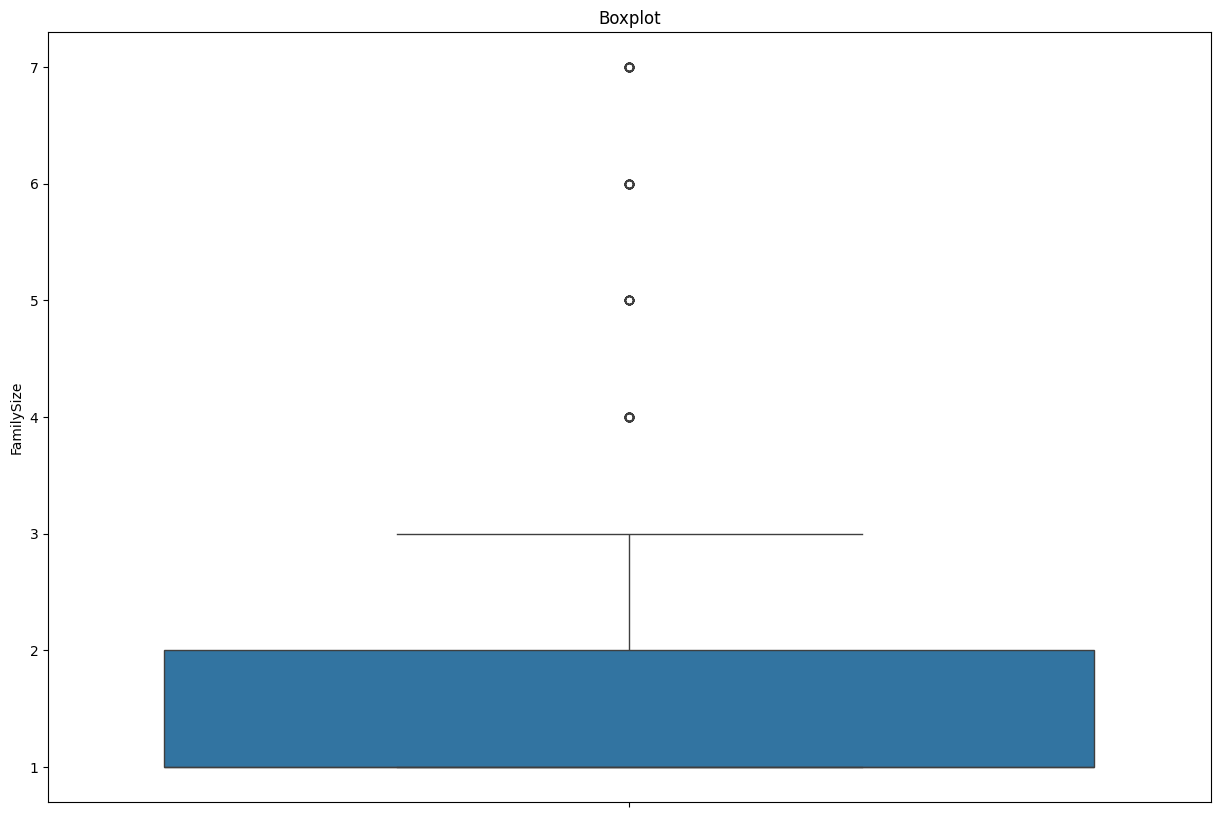

In [20]:
print(data_transformed)
plt.figure(figsize=(15, 10))
sns.boxplot(data_transformed)
plt.title(f"Boxplot")
plt.show()



EXERCISE 5